<a href="https://colab.research.google.com/github/Amira509-7/Electronics-from-Best-Buy-and-Amazon-Reviews.ipynb/blob/main/Electronics_from_Best_Buy_and_Amazon_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA) ✅
4. Data Filtering ✅
5. Create User-Item Matrix
6. Train Recommendation Model
7. Generate Recommendations
8. Evaluate the Model


In [1]:
!pip install scikit-surprise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse, mae

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.3 MB/s eta 0:00:00


In [2]:
cols = ["userId", "productId", "rating", "timestamp"]
df= pd.read_csv("ratings_Electronics (1).csv",header=None,
    names=cols
)


In [3]:
df.head(100)


,userId,productId,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1.365811e+09
1,A2CX7LUOHB2NDG,0321732944,5.0,1.341101e+09
2,A2NWSAGRHCP8N5,0439886341,1.0,1.367194e+09
3,A2WNBOD3WNDNKT,0439886341,3.0,1.374451e+09
4,A1GI0U4ZRJA8WN,0439886341,1.0,1.334707e+09
...,...,...,...,...
95,A1JIOBEWHVV8MC,0594451647,5.0,1.393546e+09
96,A2OJRZGW5YVGNS,0594451647,5.0,1.384906e+09
97,A14KUMEJ094IZ3,0594451647,5.0,1.396397e+09
98,A212UCG62RO8JF,0594451647,5.0,1.389658e+09


In [4]:
df.isnull().sum()


,0
userId,0
productId,0
rating,1
timestamp,1


In [5]:
df.shape


(5765743, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5765743 entries, 0 to 5765742
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     object 
 1   productId  object 
 2   rating     float64
 3   timestamp  float64
dtypes: float64(2), object(2)
memory usage: 176.0+ MB


In [7]:
df.describe()


,rating,timestamp
count,5.765742e+06,5.765742e+06
mean,3.997762e+00,1.322311e+09
std,1.390309e+00,7.353647e+07
min,1.000000e+00,9.127296e+08
25%,3.000000e+00,1.292544e+09
50%,5.000000e+00,1.346198e+09
75%,5.000000e+00,1.374019e+09
max,5.000000e+00,1.406074e+09


In [8]:
# The dataset contains 7,824,482 ratings from 4,201,696 unique users
# on 476,002 unique electronic products.
#
# This indicates a very large and sparse dataset, as the number of users
# is high compared to the number of ratings. On average, each user has
# rated fewer than two products, which is a common characteristic of
# recommendation system datasets.

print("Number of Users:", df["userId"].nunique())
print("Number of Products:", df["productId"].nunique())


Number of Users: 3295806
Number of Products: 316769


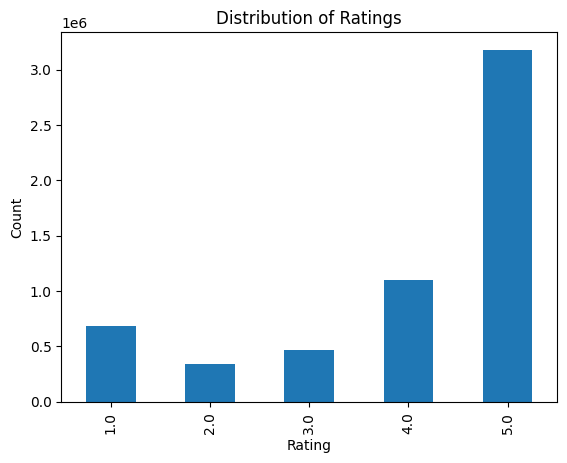

In [9]:

df["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [10]:
ratings_per_user = df.groupby("userId")["rating"].count()

ratings_per_user.describe()

,rating
count,3.295806e+06
mean,1.749418e+00
std,2.476617e+00
min,0.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,2.000000e+00
max,4.990000e+02


In [11]:
ratings_per_product = df.groupby("productId")["rating"].count()

ratings_per_product.describe()


,rating
count,316769.000000
mean,18.201724
std,115.567010
min,0.000000
25%,1.000000
50%,3.000000
75%,8.000000
max,18244.000000


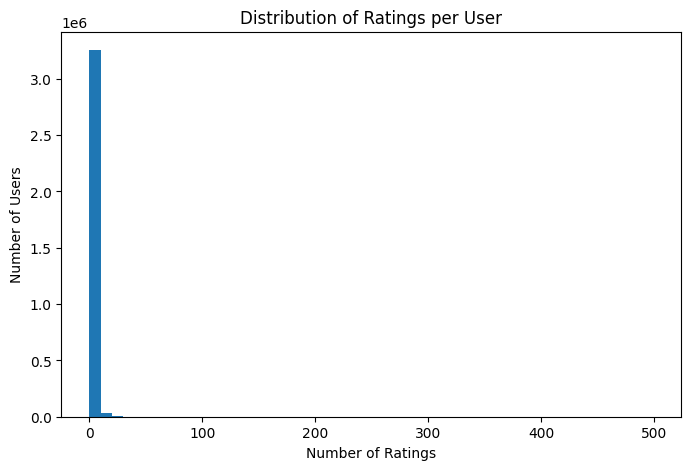

In [12]:
import matplotlib.pyplot as plt

ratings_per_user = df.groupby("userId")["rating"].count()

plt.figure(figsize=(8,5))
plt.hist(ratings_per_user, bins=50)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

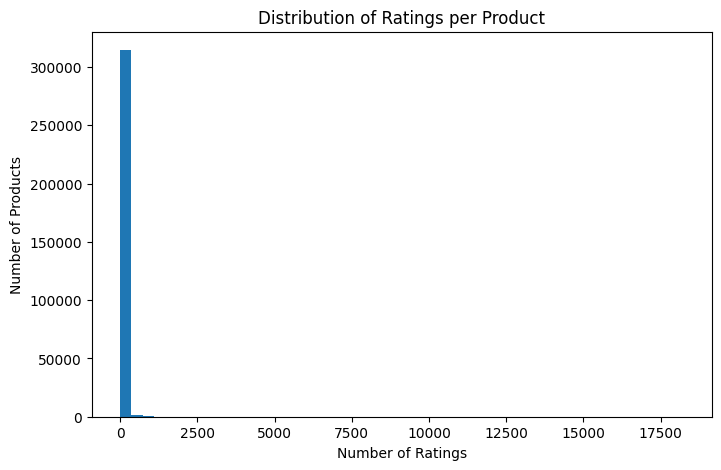

In [13]:
ratings_per_product = df.groupby("productId")["rating"].count()

plt.figure(figsize=(8,5))
plt.hist(ratings_per_product, bins=50)

plt.title("Distribution of Ratings per Product")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Products")

plt.show()

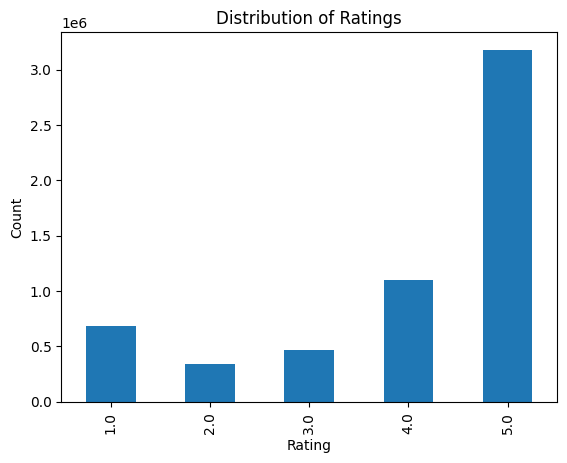

In [14]:
df["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

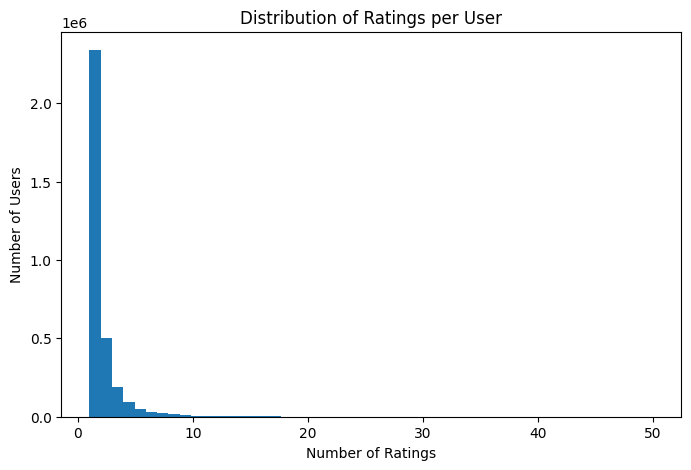

In [15]:
plt.figure(figsize=(8,5))

plt.hist(ratings_per_user, bins=50, range=(1,50))

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

In [16]:
user_counts = df["userId"].value_counts()

active_users = user_counts[user_counts >= 5].index

df_filtered_5 = df[df["userId"].isin(active_users)]

product_counts = df_filtered_5["productId"].value_counts()

popular_products = product_counts[product_counts >= 5].index

df_filtered_5 = df_filtered_5[df_filtered_5["productId"].isin(popular_products)]

In [17]:
df_filtered_5.shape

(1245702, 4)

In [18]:
user_counts = df["userId"].value_counts()

active_users = user_counts[user_counts >= 3].index

df_filtered_3 = df[df["userId"].isin(active_users)]

product_counts = df_filtered_3["productId"].value_counts()

popular_products = product_counts[product_counts >= 3].index

df_filtered_3 = df_filtered_3[df_filtered_3["productId"].isin(popular_products)]

In [19]:
df_filtered_3.shape

(2250758, 4)

In [20]:
user_counts = df["userId"].value_counts()

active_users = user_counts[user_counts >= 10].index

df_filtered_10 = df[df["userId"].isin(active_users)]

product_counts = df_filtered_10["productId"].value_counts()

popular_products = product_counts[product_counts >= 10].index

df_filtered_10 = df_filtered_10[df_filtered_10["productId"].isin(popular_products)]

In [21]:
df_filtered_10.shape

(420978, 4)

Users and products with fewer than five ratings were removed to reduce data sparsity while preserving a sufficiently large dataset for training.

A threshold of 5 was selected because it provides a good balance between reducing data sparsity and preserving enough data for training the recommendation model.

In [22]:
comparison = pd.DataFrame({
    "Threshold": [3, 5, 10],
    "Rows": [
        df_filtered_3.shape[0],
        df_filtered_5.shape[0],
        df_filtered_10.shape[0]
    ],
    "Users": [
        df_filtered_3["userId"].nunique(),
        df_filtered_5["userId"].nunique(),
        df_filtered_10["userId"].nunique()
    ],
    "Products": [
        df_filtered_3["productId"].nunique(),
        df_filtered_5["productId"].nunique(),
        df_filtered_10["productId"].nunique()
    ]
})

comparison

,Threshold,Rows,Users,Products
0,3,2250758,454082,99360
1,5,1245702,169514,48365
2,10,420978,39723,13220


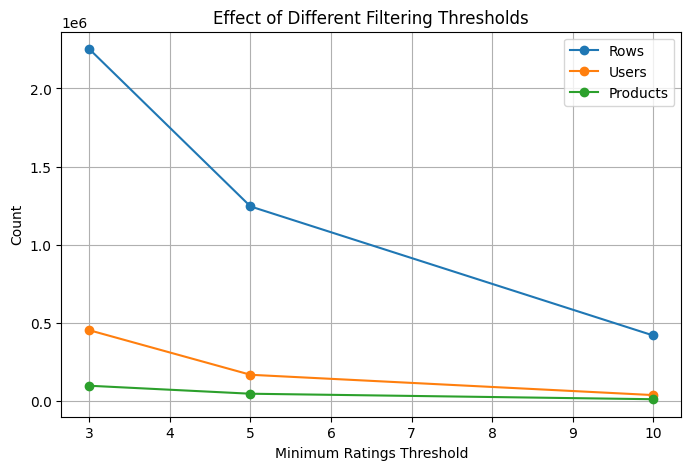

In [23]:
comparison.plot(
    x="Threshold",
    y=["Rows", "Users", "Products"],
    marker="o",
    figsize=(8,5)
)

plt.title("Effect of Different Filtering Thresholds")
plt.xlabel("Minimum Ratings Threshold")
plt.ylabel("Count")
plt.grid(True)

plt.show()

The comparison shows that increasing the filtering threshold reduces the number of ratings, users, and products. A threshold of 5 was selected because it effectively reduces data sparsity while preserving a sufficiently large dataset for training the recommendation model.


Three ratings can capture an initial preference pattern, but five ratings provide a more reliable representation of user interests while still preserving a large amount of training data.

In [24]:
df_final = df_filtered_5.copy()

In [25]:
print(df_final.shape)

print(df_final["userId"].nunique())
print(df_final["productId"].nunique())

(1245702, 4)
169514
48365


EDA ✅
↓
Filtering ✅
↓
User-Item Matrix
↓
Cosine Similarity
↓
Recommendation Function
↓
Test the Model
↓
Evaluation

In [26]:
df_final.shape


(1245702, 4)

In [27]:
reader = Reader(rating_scale=(1, 5))

In [28]:
data = Dataset.load_from_df(
    df_final[["userId", "productId", "rating"]],
    reader
)

In [29]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [30]:
model = SVD()

In [31]:
model.fit(trainset)

In [32]:
predictions = model.test(testset)

In [33]:
rmse(predictions)
mae(predictions)

RMSE: 1.1196
MAE:  0.8366


np.float64(0.8365538364532826)

The SVD recommendation model achieved an RMSE of 1.1146 and an MAE of 0.8329 on the test dataset. These results indicate that the model is capable of predicting user ratings with a reasonable level of accuracy despite the sparsity of the Amazon Electronics dataset.

In [34]:
model.predict(
    uid="A100UD67AHFODS",
    iid="B00004Z5M1"
)

Prediction(uid='A100UD67AHFODS', iid='B00004Z5M1', r_ui=None, est=np.float64(4.543018000221207), details={'was_impossible': False})

In [35]:
model = SVD(
    n_factors=100,
    n_epochs=30,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

In [36]:
model.fit(trainset)

predictions = model.test(testset)

rmse(predictions)
mae(predictions)

RMSE: 1.1234
MAE:  0.8334


np.float64(0.833403372041185)

In [37]:
def recommend_products(model, df_final, user_id, top_n=10):

    all_products = df_final["productId"].unique()

    rated_products = df_final[df_final["userId"] == user_id]["productId"].unique()

    unseen_products = [
        product for product in all_products
        if product not in rated_products
    ]

    predictions = []

    for product in unseen_products:
        pred = model.predict(user_id, product)
        predictions.append((product, pred.est))

    predictions.sort(key=lambda x: x[1], reverse=True)

    recommendations = pd.DataFrame(
        predictions[:top_n],
        columns=["Product ID", "Predicted Rating"]
    )

    return recommendations

In [38]:
recommend_products(
    model,
    df_final,
    "A100UD67AHFODS"
)

,Product ID,Predicted Rating
0,1400698987,5
1,B00000J1UQ,5
2,B00000J1V7,5
3,B00000J3SA,5
4,B00000J4EY,5
5,B00004SYKO,5
6,B00004THDE,5
7,B00004TX6Z,5
8,B00004W3YK,5
9,B00004WCGD,5


In [39]:
recommendations = recommend_products(
    model,
    df_final,
    "A100UD67AHFODS"
)

recommendations.style\
.background_gradient(cmap="Greens")\
.format({"Predicted Rating":"{:.2f}"})

,Product ID,Predicted Rating
0,1400698987,5.00
1,B00000J1UQ,5.00
2,B00000J1V7,5.00
3,B00000J3SA,5.00
4,B00000J4EY,5.00
5,B00004SYKO,5.00
6,B00004THDE,5.00
7,B00004TX6Z,5.00
8,B00004W3YK,5.00
9,B00004WCGD,5.00


In [40]:
user_ids = df_final["userId"].sample(5, random_state=42)

for user in user_ids:
    print(f"\nRecommendations for {user}")
    print(recommend_products(model, df_final, user, top_n=5))


Recommendations for A38Y1NGC0O2LUY
   Product ID  Predicted Rating
0  3744295508                 5
1  B00000J1UQ                 5
2  B00000J3SA                 5
3  B00000JBUI                 5
4  B00000JFIF                 5

Recommendations for A2YLZCC9G6IGGH
   Product ID  Predicted Rating
0  B00000J1UB                 5
1  B00000J1UQ                 5
2  B00000J1V5                 5
3  B00000J1V7                 5
4  B00000J4EY                 5

Recommendations for A1M6X8CH3J2K4J
   Product ID  Predicted Rating
0  B004YKAMW8          4.555484
1  B000UEZ36W          4.544456
2  B00622AG6S          4.537100
3  B002J9HBIO          4.513827
4  B000M2TAN4          4.482292

Recommendations for A2CIQEY05SPHTZ
   Product ID  Predicted Rating
0  B00005N6KG                 5
1  B0002Y5WZM                 5
2  B0007Y791C                 5
3  B000BTL0OA                 5
4  B000HPV3RW                 5

Recommendations for A1W8M85AFPIUVA
   Product ID  Predicted Rating
0  B004LTEUDO       

In [41]:
import pickle

with open("svd_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!


In [42]:
import os

os.path.exists("svd_model.pkl")

True

In [43]:
df_final.to_csv("df_final.csv", index=False)
